In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

In [2]:
dataset = load_dataset("papluca/language-identification")

README.md:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

C:\Users\BAO TRAN\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\BAO TRAN\.cache\huggingface\hub\datasets--papluca--language-identification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\BAO TRAN\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file

train.csv: reconstructing file:   0%|          |  0.00B / 12.0MB            

train.csv: downloading bytes:           |  0.00B            

valid.csv:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

In [4]:
dataset["train"][0]

{'labels': 'pt',
 'text': 'os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.'}

In [5]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

In [6]:
train_df.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [7]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (70000, 2)
Validation shape: (10000, 2)
Test shape: (10000, 2)


In [8]:
print(train_df.columns)

Index(['labels', 'text'], dtype='object')


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   labels  70000 non-null  object
 1   text    70000 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [10]:
print("Train missing values:")
print(train_df.isnull().sum())

print("\nValidation missing values:")
print(val_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

Train missing values:
labels    0
text      0
dtype: int64

Validation missing values:
labels    0
text      0
dtype: int64

Test missing values:
labels    0
text      0
dtype: int64


In [11]:
languages = sorted(train_df["labels"].unique())

print("Number of languages:", len(languages))
print("Languages:")
print(languages)

Number of languages: 20
Languages:
['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


In [12]:
language_names = {
    "ar": "Arabic",
    "bg": "Bulgarian",
    "de": "German",
    "el": "Greek",
    "en": "English",
    "es": "Spanish",
    "fr": "French",
    "hi": "Hindi",
    "it": "Italian",
    "ja": "Japanese",
    "nl": "Dutch",
    "pl": "Polish",
    "pt": "Portuguese",
    "ru": "Russian",
    "sw": "Swahili",
    "th": "Thai",
    "tr": "Turkish",
    "ur": "Urdu",
    "vi": "Vietnamese",
    "zh": "Chinese"
}

In [14]:
language_counts = train_df["labels"].value_counts().sort_index()

language_counts

labels
ar    3500
bg    3500
de    3500
el    3500
en    3500
es    3500
fr    3500
hi    3500
it    3500
ja    3500
nl    3500
pl    3500
pt    3500
ru    3500
sw    3500
th    3500
tr    3500
ur    3500
vi    3500
zh    3500
Name: count, dtype: int64

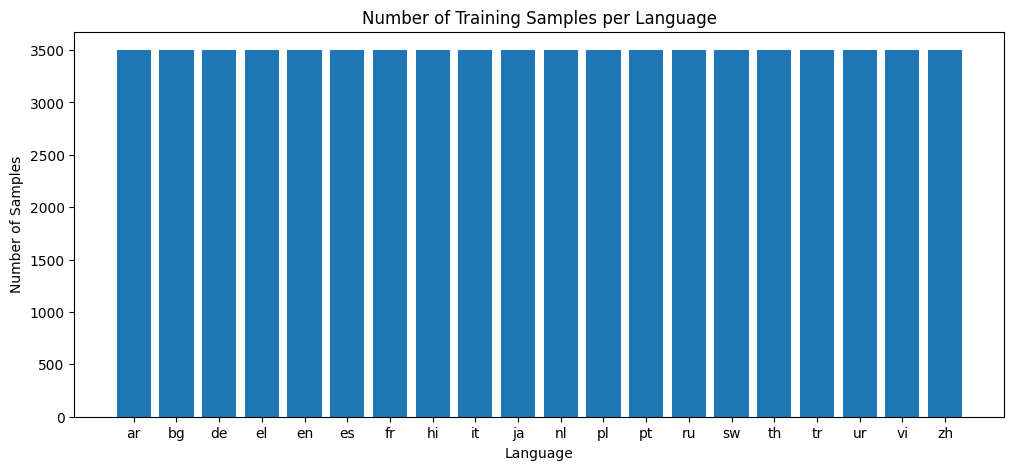

In [15]:
plt.figure(figsize=(12, 5))

plt.bar(
    language_counts.index,
    language_counts.values
)

plt.title("Number of Training Samples per Language")
plt.xlabel("Language")
plt.ylabel("Number of Samples")

plt.show()

In [16]:
for lang in languages:
    sample = train_df[
        train_df["labels"] == lang
    ].iloc[0]

    print("=" * 80)
    print(
        f"Language: {lang} - {language_names[lang]}"
    )
    print("Text:")
    print(sample["text"])
    print()

Language: ar - Arabic
Text:
نعم , هذا صحيح نعم اعتقد ان هناك خطوات كبيرة يتم صنعها في الوقت الحاضر في رعاية المسنين الذين تعرفهم في العديد من المناطق

Language: bg - Bulgarian
Text:
размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до около 100 km за на симулация .

Language: de - German
Text:
Alles in allem ein super schönes Teil, deshalb die 2 Sterne! Denn: Voice Control?! Nein, ein absoluter Witz. Die reagiert nämlich nur bedingt und wenn sie gerade meint. Sprachbefehle sind, egal wie man sie ausspricht, ein Glückstreffer. Meine Freundin sagte z.B. zu mir- naja ist eben ein Weib. Daraufhin schaltete sich der Akkuträger aus bzw fragte ob ich mir sicher bin ob ich ihn ausmachen möchte.... Zusätzlich kam das Teil bei mir mit kaputtem Glastank an. Da Amazon nicht selbst der Verkäufer ist, gibt es nur die Option der Rücksendung. Schade, denn das Gerät sieht super aus und liegt schön in der Hand. Allerdings ist eben die Sprachsteuerung eine 

In [17]:
duplicate_count = train_df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 1020


In [18]:
duplicate_text_count = train_df["text"].duplicated().sum()

print(
    "Number of duplicated texts:",
    duplicate_text_count
)

Number of duplicated texts: 1022


In [20]:
train_df["text_length"] = train_df["text"].str.len()
train_df[
    ["labels", "text", "text_length"]
].head()

,labels,text,text_length
0,pt,"os chefes de defesa da estónia, letónia, lituâ...",161
1,bg,размерът на хоризонталната мрежа може да бъде ...,131
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,112
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,141
4,ru,Он увеличил давление .,22


In [21]:
train_df["text_length"].describe()

count    70000.000000
mean       110.861414
std        103.106240
min          2.000000
25%         47.000000
50%         82.000000
75%        143.000000
max       2422.000000
Name: text_length, dtype: float64

In [22]:
train_df.loc[
    train_df["text_length"].idxmin(),
    ["labels", "text", "text_length"]
]

labels         ar
text           حي
text_length     2
Name: 29229, dtype: object

In [23]:
train_df.loc[
    train_df["text_length"].idxmax(),
    ["labels", "text", "text_length"]
]

labels                                                        fr
text           Bonjour à tous, Il est rare que je fasse des é...
text_length                                                 2422
Name: 49552, dtype: object

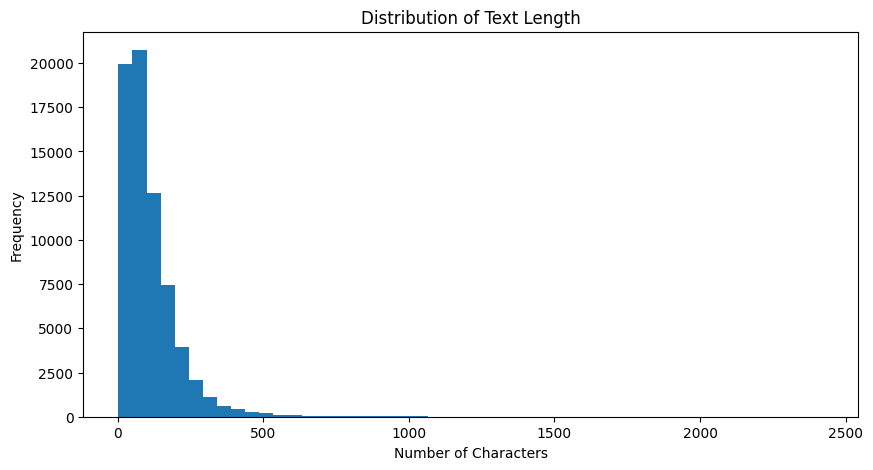

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["text_length"],
    bins=50
)

plt.title("Distribution of Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

In [27]:
avg_length_by_language = (
    train_df
    .groupby("labels")["text_length"]
    .mean()
    .sort_values()
)

avg_length_by_language

labels
zh     50.752857
pl     63.584000
nl     66.827429
pt     66.870857
it     69.972286
ur     84.693143
ar     97.207714
ja    100.169429
tr    102.220857
sw    107.212000
bg    114.118286
hi    115.925714
th    116.604571
ru    117.315143
vi    121.268857
el    125.921714
es    151.092286
fr    159.574857
en    180.069429
de    205.826857
Name: text_length, dtype: float64

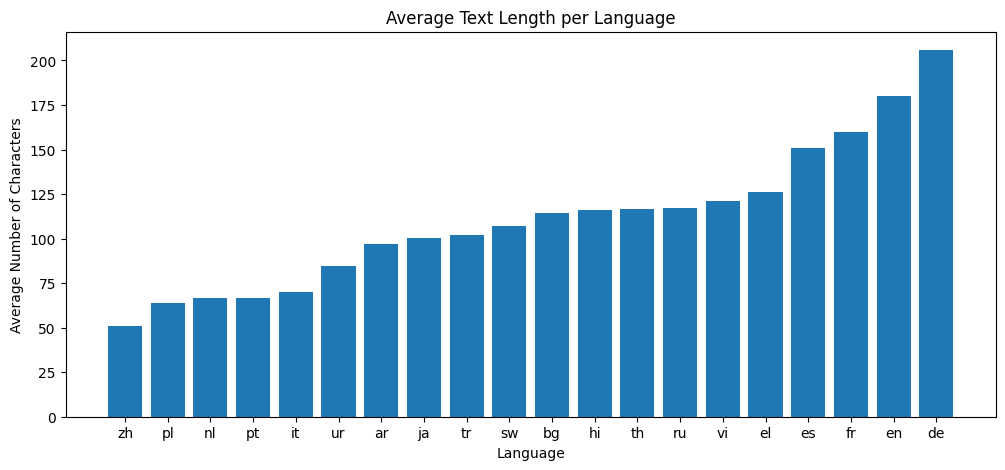

In [28]:
plt.figure(figsize=(12, 5))

plt.bar(
    avg_length_by_language.index,
    avg_length_by_language.values
)

plt.title("Average Text Length per Language")
plt.xlabel("Language")
plt.ylabel("Average Number of Characters")

plt.show()

In [29]:
os.makedirs("../data/raw", exist_ok=True)

In [30]:
dataset["train"].to_pandas().to_csv(
    "../data/raw/train.csv",
    index=False
)

dataset["validation"].to_pandas().to_csv(
    "../data/raw/validation.csv",
    index=False
)

dataset["test"].to_pandas().to_csv(
    "../data/raw/test.csv",
    index=False
)

print("Raw dataset saved successfully!")

Raw dataset saved successfully!


In [31]:
print(os.listdir("../data/raw"))

['test.csv', 'train.csv', 'validation.csv']


In [32]:
for file in os.listdir("../data/raw"):
    file_path = os.path.join(
        "../data/raw",
        file
    )

    size_mb = os.path.getsize(file_path) / (1024 ** 2)

    print(
        f"{file}: {size_mb:.2f} MB"
    )

test.csv: 1.62 MB
train.csv: 11.46 MB
validation.csv: 1.64 MB


In [33]:
test_load = pd.read_csv(
    "../data/raw/train.csv"
)

test_load.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [34]:
print(test_load.shape)
print(test_load.columns)

(70000, 2)
Index(['labels', 'text'], dtype='object')


## Kết luận

- Dataset gồm tổng cộng 90.000 mẫu văn bản.
- Dữ liệu được chia thành 3 tập: train, validation và test.
- Dataset bao gồm 20 ngôn ngữ khác nhau.
- Số lượng mẫu của các ngôn ngữ trong tập train được phân bố đồng đều, cho thấy dataset tương đối cân bằng.
- Ở giai đoạn này, dữ liệu chưa được tiền xử lý.
- Dataset gốc đã được lưu vào thư mục `data/raw` để sử dụng cho các bước tiếp theo.